# Analisando Dados - Produção Hospitalar

## Pré-processamento de Dados

In [2]:
import pandas as pd

In [3]:
pd.options.display.float_format = '{:.2f}'.format

In [4]:
file_1 = 'A150850189_28_143_208.csv'
file_2 = 'A152918189_28_143_208.csv'

df = pd.read_csv(file_1, sep=';', encoding='ISO-8859-1', skiprows= 3, skipfooter=12, thousands='.', decimal=',', engine='python')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27 entries, 0 to 26
Columns: 293 entries, Unidade da Federação to Total
dtypes: float64(170), object(123)
memory usage: 61.9+ KB


In [6]:
df.describe()

,2007/Ago,2007/Set,2007/Out,2007/Nov,2007/Dez,2008/Jan,2008/Fev,2008/Mar,2008/Abr,2008/Mai,...,2020/Dez,2021/Jan,2021/Fev,2021/Mar,2021/Abr,2021/Mai,2021/Jun,2021/Jul,2021/Ago,Total
count,27.00,27.00,27.00,27.00,27.00,27.00,27.00,27.00,27.00,27.00,...,27.00,27.00,27.00,27.00,27.00,27.00,27.00,27.00,27.00,27.00
mean,304952.77,788145.26,2440162.96,5517354.05,12337159.42,76872923.93,23825025.66,25882844.71,26215278.28,26221049.45,...,57043175.42,58917158.65,59070927.95,81749309.03,81142931.26,87271862.20,77590406.47,60846287.01,43885716.30,6852320913.49
std,392806.00,1071747.56,3421972.10,7767711.29,16345863.65,203345357.97,34476004.08,34826830.50,34796463.86,35071861.23,...,71812939.93,75886774.58,74250282.54,104151498.28,103731994.30,113210161.00,103596516.21,82898209.94,62018534.41,9169866693.74
min,4113.76,11858.63,43852.67,226661.18,470676.43,808448.39,771687.83,876091.18,896952.53,1027288.73,...,2841469.69,2786277.13,2664375.13,3960131.30,4192540.54,3681417.80,3458187.11,2302711.01,1196754.85,337181964.14
25%,46580.42,139423.94,505778.42,1410610.81,3650090.00,8257222.37,7932273.51,8926011.35,8764559.62,9229049.70,...,19073133.75,19522001.10,20977269.17,29399477.97,26964958.13,27262112.33,24095597.98,18724376.30,11348430.84,2224263694.82
50%,179395.82,418053.58,1152115.25,2406035.32,5949408.99,16599004.84,10215956.80,12262049.08,12453466.98,11900817.00,...,29093489.77,27452425.03,28344652.94,37147348.21,38411419.09,41819897.10,34937134.14,29364200.76,20837865.89,2867428082.03
75%,392985.52,969999.75,2625635.63,5915821.61,13394973.35,52156843.27,26932691.98,30400866.02,30982776.89,31307258.67,...,79372320.79,79191784.05,81887992.15,100967867.00,108236362.28,117460819.75,106300830.46,79844137.72,55265343.61,8818298482.19
max,1665349.90,4434168.64,14577395.84,35032259.98,76668547.41,1049827695.26,173062308.33,170621304.31,170389849.75,172513744.39,...,338634303.39,361427087.80,352846447.86,502905607.53,504427182.45,548112705.83,503160959.54,404373175.61,301986341.98,44290790025.14


## Aula 5 - Manipulação e interpretação de gráficos

In [7]:
import numpy as np
import matplotlib.pyplot as plt

In [8]:
df.replace('-', np.nan, inplace=True)
df.dropna(axis=1, inplace=True)
df.set_index('Unidade da Federação', inplace=True)
df.sort_values(by='Total', ascending=False, inplace=True)
df.drop(columns='Total',axis= 1, inplace=True)

In [9]:
df = df.iloc[:, 6:]

In [10]:
last_column = df.columns[-1]

In [11]:
df_last_columns = df[last_column]

In [12]:
df_last_columns = df_last_columns /1_000_000

In [24]:
df_last_columns.head(10)

Unidade da Federação
35 São Paulo           301.99
31 Minas Gerais        139.16
41 Paraná               91.19
43 Rio Grande do Sul    74.95
33 Rio de Janeiro       94.14
29 Bahia                61.65
26 Pernambuco           71.63
42 Santa Catarina       48.88
23 Ceará                35.65
52 Goiás                44.94
Name: 2021/Ago, dtype: float64

In [30]:
# Mostrando por porcentagem de Paraná com relações a outros estados.
(df_last_columns/ df_last_columns.loc['41 Paraná']).round(2).astype(str) + '%'

Unidade da Federação
35 São Paulo              3.31%
31 Minas Gerais           1.53%
41 Paraná                  1.0%
43 Rio Grande do Sul      0.82%
33 Rio de Janeiro         1.03%
29 Bahia                  0.68%
26 Pernambuco             0.79%
42 Santa Catarina         0.54%
23 Ceará                  0.39%
52 Goiás                  0.49%
15 Pará                   0.23%
21 Maranhão               0.28%
32 Espírito Santo          0.3%
24 Rio Grande do Norte    0.18%
25 Paraíba                0.18%
53 Distrito Federal       0.24%
50 Mato Grosso do Sul     0.12%
22 Piauí                  0.17%
27 Alagoas                0.12%
51 Mato Grosso            0.22%
13 Amazonas               0.15%
28 Sergipe                0.05%
17 Tocantins              0.03%
11 Rondônia               0.08%
12 Acre                   0.01%
14 Roraima                0.03%
16 Amapá                  0.02%
Name: 2021/Ago, dtype: object

In [ ]:
tabela_comparacao = df_last_columns / df_last_columns.loc['41 Paraná']

<Axes: xlabel='Unidade da Federação'>

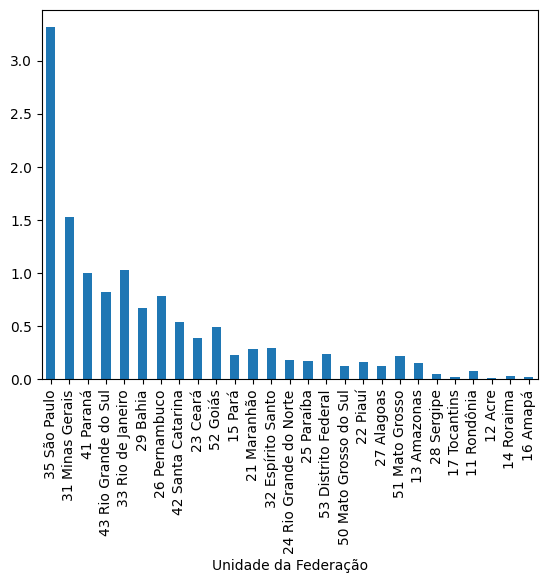

In [32]:
tabela_comparacao.plot(kind='bar')

## Desafios

> Passar uma linha na horizontal no seu estado. Anotando o gráfico com uma linha.

> Atualizar o último gráfico para refletir seu estado, incluindo grid, eixos e etc.

> Colorir seu estado com um tom diferente. Colorir os outros estados de acordo com gasto maior ou menor

> Gasto por população de dois estados. Escolher dois estados, plotar a comparação desses gastos de acordo com a população deles (base IBGE por exemplo)

> Explore gráficos e as tabelas, encontre o que você acha de interessante, levante perguntas e hipóteses.

> Escolha outro valor além de 'Valor aprovado' no tabnet.